## Loan approval prediction using machine learning

In [76]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [41]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Loan_CData.csv")

In [42]:
df

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [43]:
df.shape

(614, 13)

In [44]:
df.size

7982

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         614 non-null    int64  
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


In [46]:
df.dtypes

Unnamed: 0             int64
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [47]:
df.columns

Index(['Unnamed: 0', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [48]:
df.head()

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [49]:
df.tail()

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,613,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [50]:
df.describe()

,Unnamed: 0,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,306.500000,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,177.390811,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,153.250000,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,306.500000,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,459.750000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,613.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [51]:
df.isnull().sum()

Unnamed: 0           0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [52]:
df.nunique()

Unnamed: 0           614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [53]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool

In [54]:
df.value_counts()

Unnamed: 0  Gender  Married  Dependents  Education     Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  Property_Area  Loan_Status
0           Male    No       0           Graduate      No             5849             0.0                128.0       360.0             1.0             Urban          Y              1
412         Male    Yes      0           Not Graduate  No             6096             0.0                218.0       360.0             0.0             Rural          N              1
405         Female  No       0           Graduate      No             4547             0.0                115.0       360.0             1.0             Semiurban      Y              1
406         Male    Yes      0           Not Graduate  No             2167             2400.0             115.0       360.0             1.0             Urban          Y              1
407         Female  No       0           Not Graduate  No             2213           

In [55]:
df=df.drop(columns=["Unnamed: 0"])

In [56]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Loan status distribution

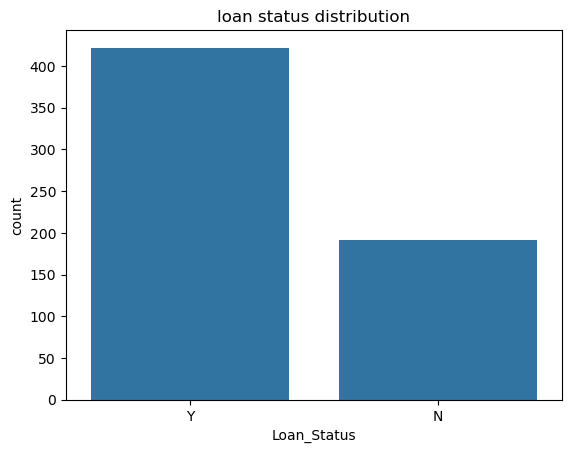

In [58]:
sns.countplot(x="Loan_Status",data=df)
plt.title("loan status distribution")
plt.show()

## Interpretation

### semiurban areas have more approved loans compared with urban and rural areas

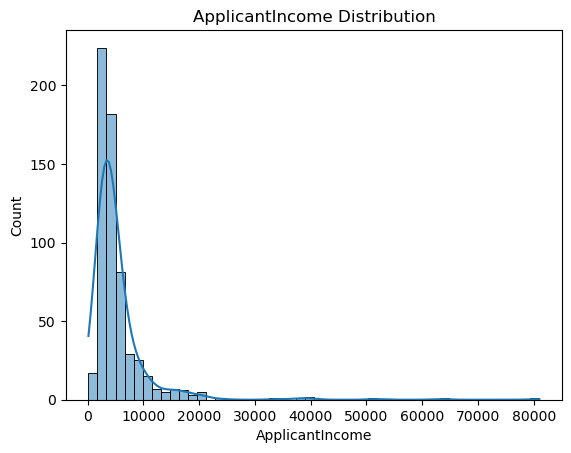

In [60]:
sns.histplot(df["ApplicantIncome"],kde=True)
plt.title("ApplicantIncome Distribution")
plt.show()

## Interpretation

### Most applicant have lower income,while only a few have very high income

## Seperate Features and Target

In [62]:
x=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [63]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: object

## Encoding

In [64]:
categorical_cols=x.select_dtypes(include="object").columns
print(categorical_cols)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


In [65]:
x=pd.get_dummies(x,columns=categorical_cols,drop_first=True)

In [66]:
x.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True


In [67]:
x=x.astype(int)

In [68]:
x

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0,128,360,1,1,0,0,0,0,0,0,0,1
1,4583,1508,128,360,1,1,1,1,0,0,0,0,0,0
2,3000,0,66,360,1,1,1,0,0,0,0,1,0,1
3,2583,2358,120,360,1,1,1,0,0,0,1,0,0,1
4,6000,0,141,360,1,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0,71,360,1,0,0,0,0,0,0,0,0,0
610,4106,0,40,180,1,1,1,0,0,1,0,0,0,0
611,8072,240,253,360,1,1,1,1,0,0,0,0,0,1
612,7583,0,187,360,1,1,1,0,1,0,0,0,0,1


## Train Test Split

In [69]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [70]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("Y_test:",Y_test.shape)
print("Y_train:",Y_train.shape)

X_train: (491, 14)
X_test: (123, 14)
Y_test: (123,)
Y_train: (491,)


## Scaling

In [71]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [73]:
X_train_scaled

array([[-0.352802  , -0.56322745, -1.13158849, ..., -0.40776315,
        -0.77417604,  1.42508393],
       [-0.3433464 , -0.56322745, -0.59230932, ..., -0.40776315,
         1.29169589, -0.70171306],
       [-0.33947116,  0.0504056 ,  0.04075753, ..., -0.40776315,
        -0.77417604, -0.70171306],
       ...,
       [-0.42333146,  0.24526101, -0.28749936, ..., -0.40776315,
         1.29169589, -0.70171306],
       [-0.47215955,  0.26284464, -0.11164745, ..., -0.40776315,
         1.29169589, -0.70171306],
       [-0.48161515, -0.38200834, -0.19371168, ..., -0.40776315,
         1.29169589, -0.70171306]], shape=(491, 14))

In [74]:
X_test_scaled

array([[ 0.11579264, -0.56322745, -0.3343932 , ..., -0.40776315,
        -0.77417604, -0.70171306],
       [-0.20926292,  0.26428004,  0.41590826, ..., -0.40776315,
         1.29169589, -0.70171306],
       [ 0.68715878, -0.56322745,  0.39246133, ...,  2.45240407,
        -0.77417604, -0.70171306],
       ...,
       [-0.38659414,  0.33533229,  0.13454521, ..., -0.40776315,
         1.29169589, -0.70171306],
       [ 0.61662932, -0.56322745,  0.47452556, ..., -0.40776315,
        -0.77417604, -0.70171306],
       [-0.38256388,  0.14980698, -0.41645742, ..., -0.40776315,
        -0.77417604,  1.42508393]], shape=(123, 14))

## Model building

In [77]:
model=LogisticRegression()

In [78]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [79]:
model.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [80]:
y_pred=model.predict(X_test_scaled)

In [81]:
y_pred

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'Y', 'N'], dtype=object)

In [83]:
x.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [88]:
print("Loan Prediction")
print("-" * 20)

ApplicantIncome = float(input("Enter Applicant Income: "))
CoapplicantIncome = float(input("Enter Coapplicant Income: "))
LoanAmount = float(input("Enter Loan Amount: "))
Loan_Amount_Term = float(input("Enter Loan Amount Term: "))
Credit_History = float(input("Enter Credit History (0/1): "))

Gender = input("Enter Gender (Male/Female): ")
Married = input("Enter Married (Yes/No): ")
Dependents = input("Enter Dependents (0/1/2/3+): ")
Education = input("Enter Education (Graduate/Not Graduate): ")
Self_Employed = input("Enter Self Employed (Yes/No): ")
Property_Area = input("Enter Property Area (Rural/Semiurban/Urban): ")


new_data = pd.DataFrame({
    'ApplicantIncome': [ApplicantIncome],
    'CoapplicantIncome': [CoapplicantIncome],
    'LoanAmount': [LoanAmount],
    'Loan_Amount_Term': [Loan_Amount_Term],
    'Credit_History': [Credit_History],
    'Gender_Male': [1 if Gender == "Male" else 0],
    'Married_Yes': [1 if Married == "Yes" else 0],
    'Dependents_1': [1 if Dependents == "1" else 0],
    'Dependents_2': [1 if Dependents == "2" else 0],
    'Dependents_3+': [1 if Dependents == "3+" else 0],
    'Education_Not Graduate': [1 if Education == "Not Graduate" else 0],
    'Self_Employed_Yes': [1 if Self_Employed == "Yes" else 0],
    'Property_Area_Semiurban': [1 if Property_Area == "Semiurban" else 0],
    'Property_Area_Urban': [1 if Property_Area == "Urban" else 0]
})

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nPrediction")
print("-" * 20)
print(prediction[0])

Loan Prediction
--------------------


Enter Applicant Income:  60000
Enter Coapplicant Income:  40000
Enter Loan Amount:  50000
Enter Loan Amount Term:  5000
Enter Credit History (0/1):  1
Enter Gender (Male/Female):  1
Enter Married (Yes/No):  1
Enter Dependents (0/1/2/3+):  1
Enter Education (Graduate/Not Graduate):  0
Enter Self Employed (Yes/No):  1
Enter Property Area (Rural/Semiurban/Urban):  1



Prediction
--------------------
N
